# Phase 1: Exploratory Data Analysis
## Santander Product Recommendation — Next Product to Buy

**Objective:** Understand the dataset structure, identify data quality issues, and discover patterns in customer product adoption.

**Business Context:** Santander Bank wants to predict which products a customer will newly purchase next month. This EDA will help us understand:
- Customer demographics and their relationship with product ownership
- Product popularity and co-occurrence patterns
- Temporal trends in product adoption
- Data quality issues that need handling before modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading

The dataset is large (~2.4GB). We'll use chunked reading and dtype optimization to manage memory.

In [2]:
DATA_PATH = Path('../data/raw/train_ver2.csv')

# Column dtypes for memory optimization
dtype_dict = {
    'ncodpers': 'int32',
    'ind_empleado': 'category',
    'pais_residencia': 'category',
    'sexo': 'category',
    'ind_nuevo': 'float16',
    'indrel': 'float16',
    'indrel_1mes': 'category',
    'tiprel_1mes': 'category',
    'indresi': 'category',
    'indext': 'category',
    'canal_entrada': 'category',
    'indfall': 'category',
    'nomprov': 'category',
    'ind_actividad_cliente': 'float16',
    'segmento': 'category',
}

# Product columns (24 binary flags)
product_cols = [
    'ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1',
    'ind_cder_fin_ult1', 'ind_cno_fin_ult1', 'ind_ctju_fin_ult1',
    'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1',
    'ind_deco_fin_ult1', 'ind_deme_fin_ult1', 'ind_dela_fin_ult1',
    'ind_ecue_fin_ult1', 'ind_fond_fin_ult1', 'ind_hip_fin_ult1',
    'ind_plan_fin_ult1', 'ind_pres_fin_ult1', 'ind_reca_fin_ult1',
    'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1', 'ind_viv_fin_ult1',
    'ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1'
]

# Product readable names for visualization
product_names = {
    'ind_ahor_fin_ult1': 'Saving Account',
    'ind_aval_fin_ult1': 'Guarantees',
    'ind_cco_fin_ult1': 'Current Account',
    'ind_cder_fin_ult1': 'Derivada Account',
    'ind_cno_fin_ult1': 'Payroll Account',
    'ind_ctju_fin_ult1': 'Junior Account',
    'ind_ctma_fin_ult1': 'Más Particular Account',
    'ind_ctop_fin_ult1': 'Particular Account',
    'ind_ctpp_fin_ult1': 'Particular Plus Account',
    'ind_deco_fin_ult1': 'Short-term Deposits',
    'ind_deme_fin_ult1': 'Medium-term Deposits',
    'ind_dela_fin_ult1': 'Long-term Deposits',
    'ind_ecue_fin_ult1': 'e-Account',
    'ind_fond_fin_ult1': 'Funds',
    'ind_hip_fin_ult1': 'Mortgage',
    'ind_plan_fin_ult1': 'Pensions',
    'ind_pres_fin_ult1': 'Loans',
    'ind_reca_fin_ult1': 'Taxes',
    'ind_tjcr_fin_ult1': 'Credit Card',
    'ind_valo_fin_ult1': 'Securities',
    'ind_viv_fin_ult1': 'Home Account',
    'ind_nomina_ult1': 'Payroll',
    'ind_nom_pens_ult1': 'Pensions (Payroll)',
    'ind_recibo_ult1': 'Direct Debit'
}

print(f'Data path: {DATA_PATH}')
print(f'Number of product columns: {len(product_cols)}')

Data path: ../data/raw/train_ver2.csv
Number of product columns: 24


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['fecha_dato', 'fecha_alta'],
    low_memory=False
)

print("Before optimization:",
      df.memory_usage(deep=True).sum() / 1e9, "GB")


# 1️⃣ Object → category
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')


# 2️⃣ Integer küçültme
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')


# 3️⃣ Float küçültme
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')


print("After optimization:",
      df.memory_usage(deep=True).sum() / 1e9, "GB")

Before optimization: 5.908657316 GB
After optimization: 1.310155265 GB


In [ ]:
# ALTERNATIVE: If memory is limited, load only last 6 months
# Uncomment below and comment out the cell above

# df = pd.read_csv(DATA_PATH, dtype=dtype_dict, parse_dates=['fecha_dato', 'fecha_alta'], low_memory=False)
# df = df[df['fecha_dato'] >= '2015-12-28']
# df = df.reset_index(drop=True)
# print(f'Shape (last 6 months): {df.shape}')

## 2. Data Overview

In [7]:
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Unique customers: {df["ncodpers"].nunique():,}')
print(f'Date range: {df["fecha_dato"].min()} to {df["fecha_dato"].max()}')
print(f'Months covered: {df["fecha_dato"].nunique()}')
print()
print('Column types:')
print(df.dtypes.value_counts())

DATASET OVERVIEW
Rows: 13,647,309
Columns: 48
Unique customers: 956,645
Date range: 2015-01-28 00:00:00 to 2016-05-28 00:00:00
Months covered: 17

Column types:
int8              22
float32            7
category           4
datetime64[us]     2
int32              1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
float64            1
category           1
Name: count, dtype: int64


In [8]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)} / {df.shape[1]}')
print()
print(missing_df.to_string())

Columns with missing values: 22 / 48

                       missing_count  missing_pct
conyuemp                    13645501        99.99
ult_fec_cli_1t              13622516        99.82
renta                        2794375        20.48
segmento                      189368         1.39
canal_entrada                 186126         1.36
indrel_1mes                   149781         1.10
tiprel_1mes                   149781         1.10
nomprov                        93591         0.69
cod_prov                       93591         0.69
ind_actividad_cliente          27734         0.20
tipodom                        27735         0.20
indfall                        27734         0.20
ind_empleado                   27734         0.20
pais_residencia                27734         0.20
indext                         27734         0.20
indresi                        27734         0.20
indrel                         27734         0.20
ind_nuevo                      27734         0.20
fecha_alta  

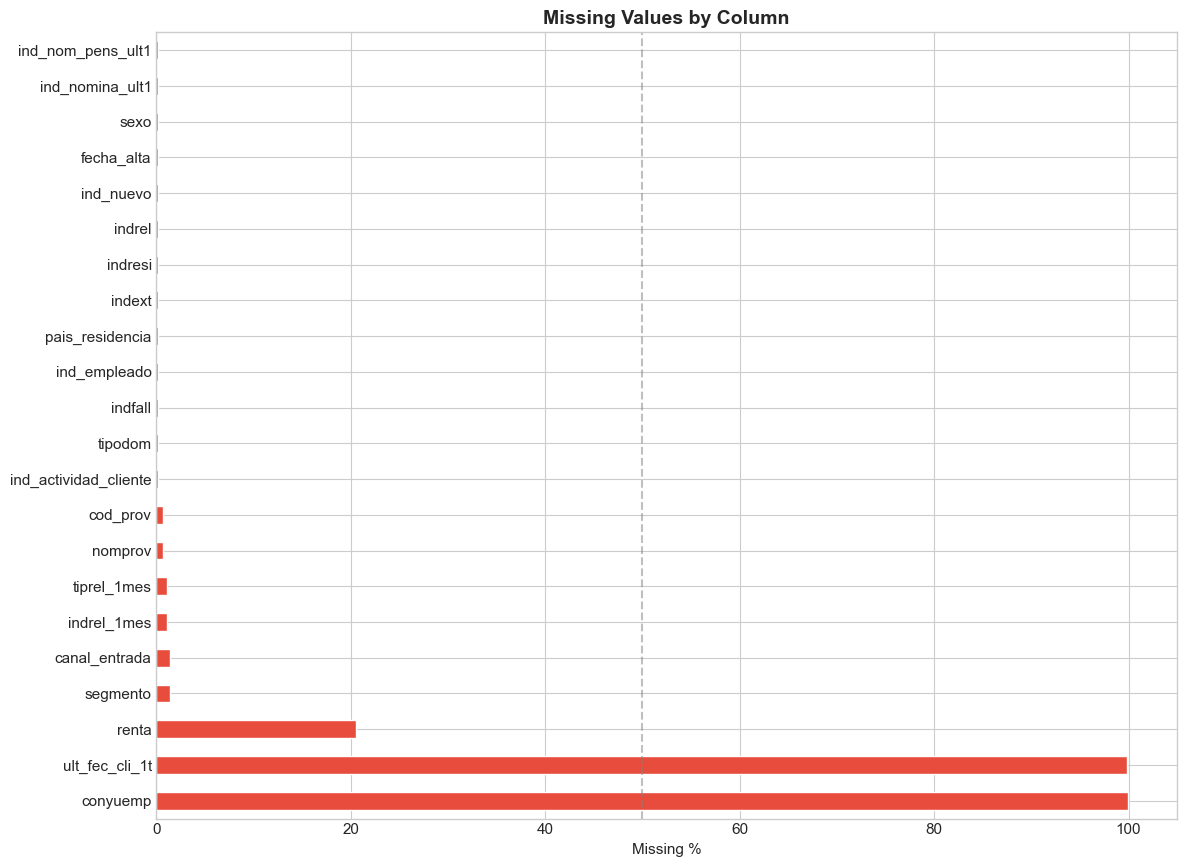

In [9]:
# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(6, len(missing_df) * 0.4)))
    missing_df['missing_pct'].plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('../outputs/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Product Analysis

Understanding which products are popular, how they co-occur, and how adoption changes over time.

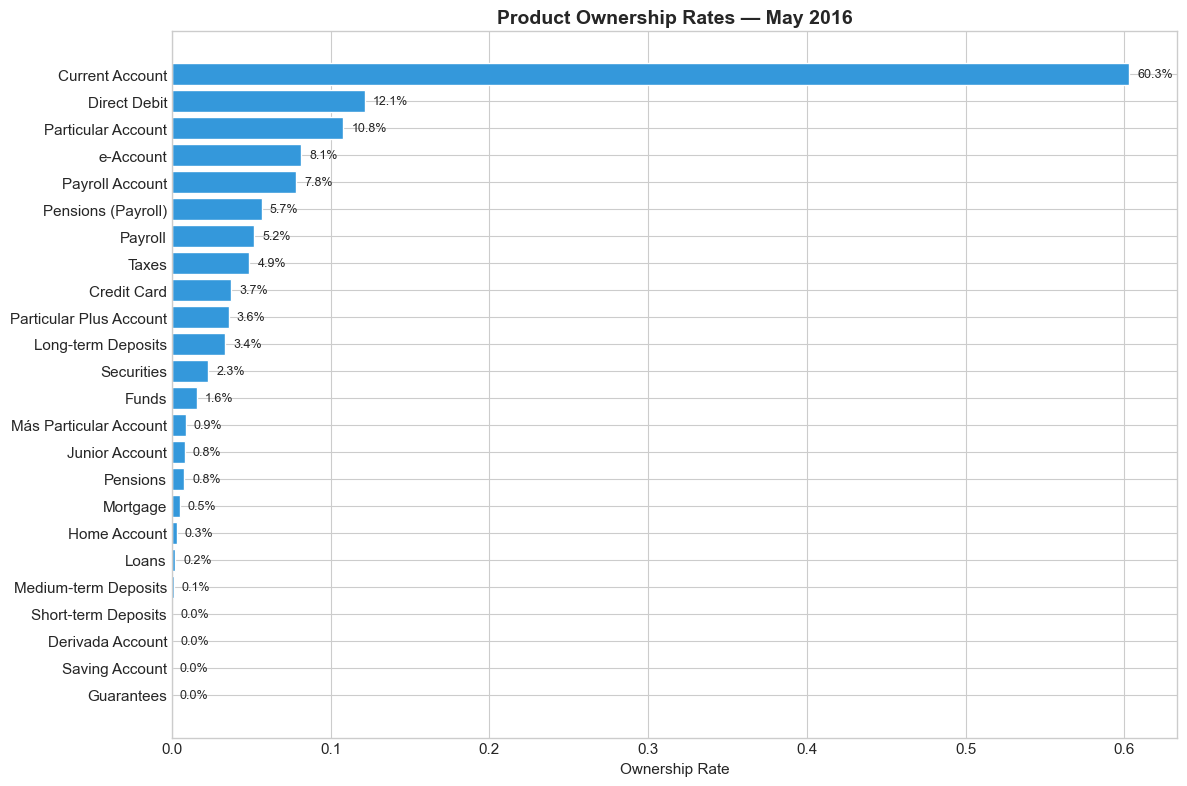

In [10]:
# Product ownership rates (latest month)
latest_month = df['fecha_dato'].max()
latest = df[df['fecha_dato'] == latest_month]

product_rates = latest[product_cols].mean().sort_values(ascending=True)
product_labels = [product_names.get(c, c) for c in product_rates.index]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(product_labels, product_rates.values, color='#3498db', edgecolor='white')
ax.set_xlabel('Ownership Rate')
ax.set_title(f'Product Ownership Rates — {latest_month.strftime("%B %Y")}', fontsize=14, fontweight='bold')

# Add percentage labels
for bar, val in zip(bars, product_rates.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/product_ownership_rates.png', dpi=150, bbox_inches='tight')
plt.show()

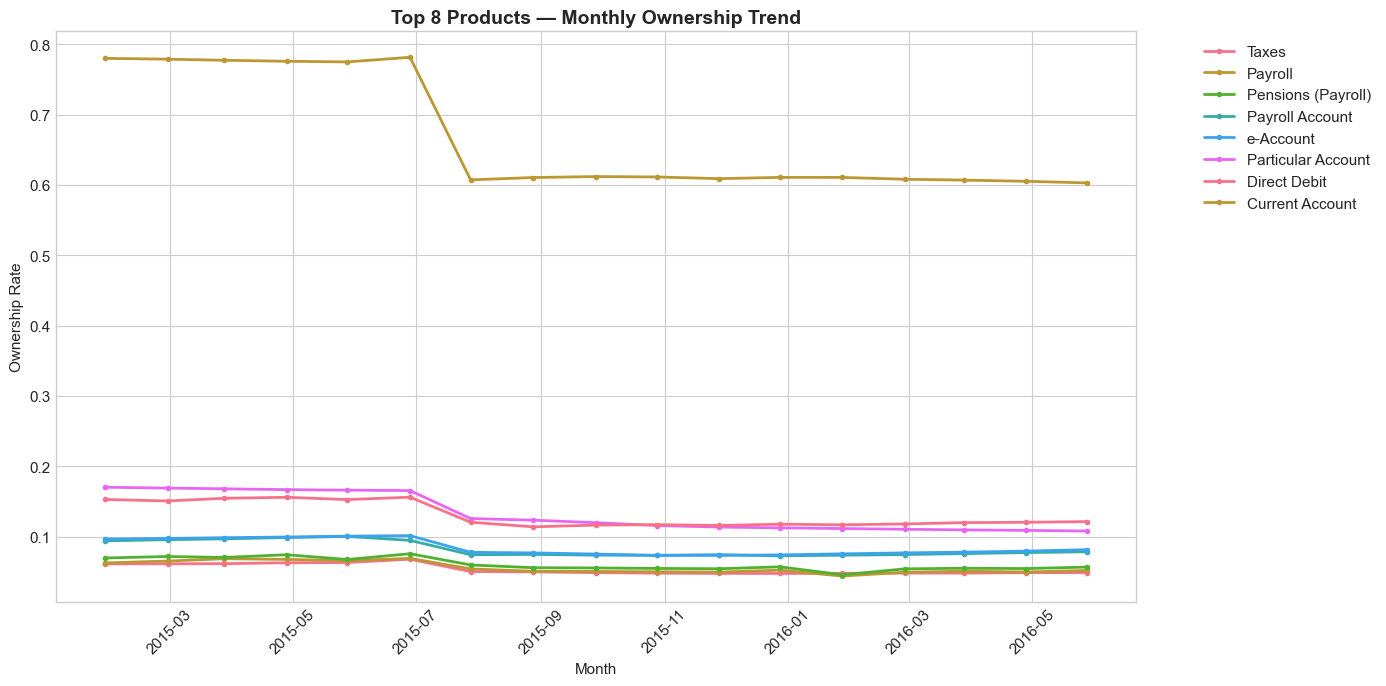

In [11]:
# Product adoption over time (monthly)
monthly_products = df.groupby('fecha_dato')[product_cols].mean()

# Top 8 products by final month ownership
top_products = product_rates.tail(8).index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))
for col in top_products:
    ax.plot(monthly_products.index, monthly_products[col], marker='o', markersize=3, 
            label=product_names.get(col, col), linewidth=2)

ax.set_xlabel('Month')
ax.set_ylabel('Ownership Rate')
ax.set_title('Top 8 Products — Monthly Ownership Trend', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/product_trends.png', dpi=150, bbox_inches='tight')
plt.show()

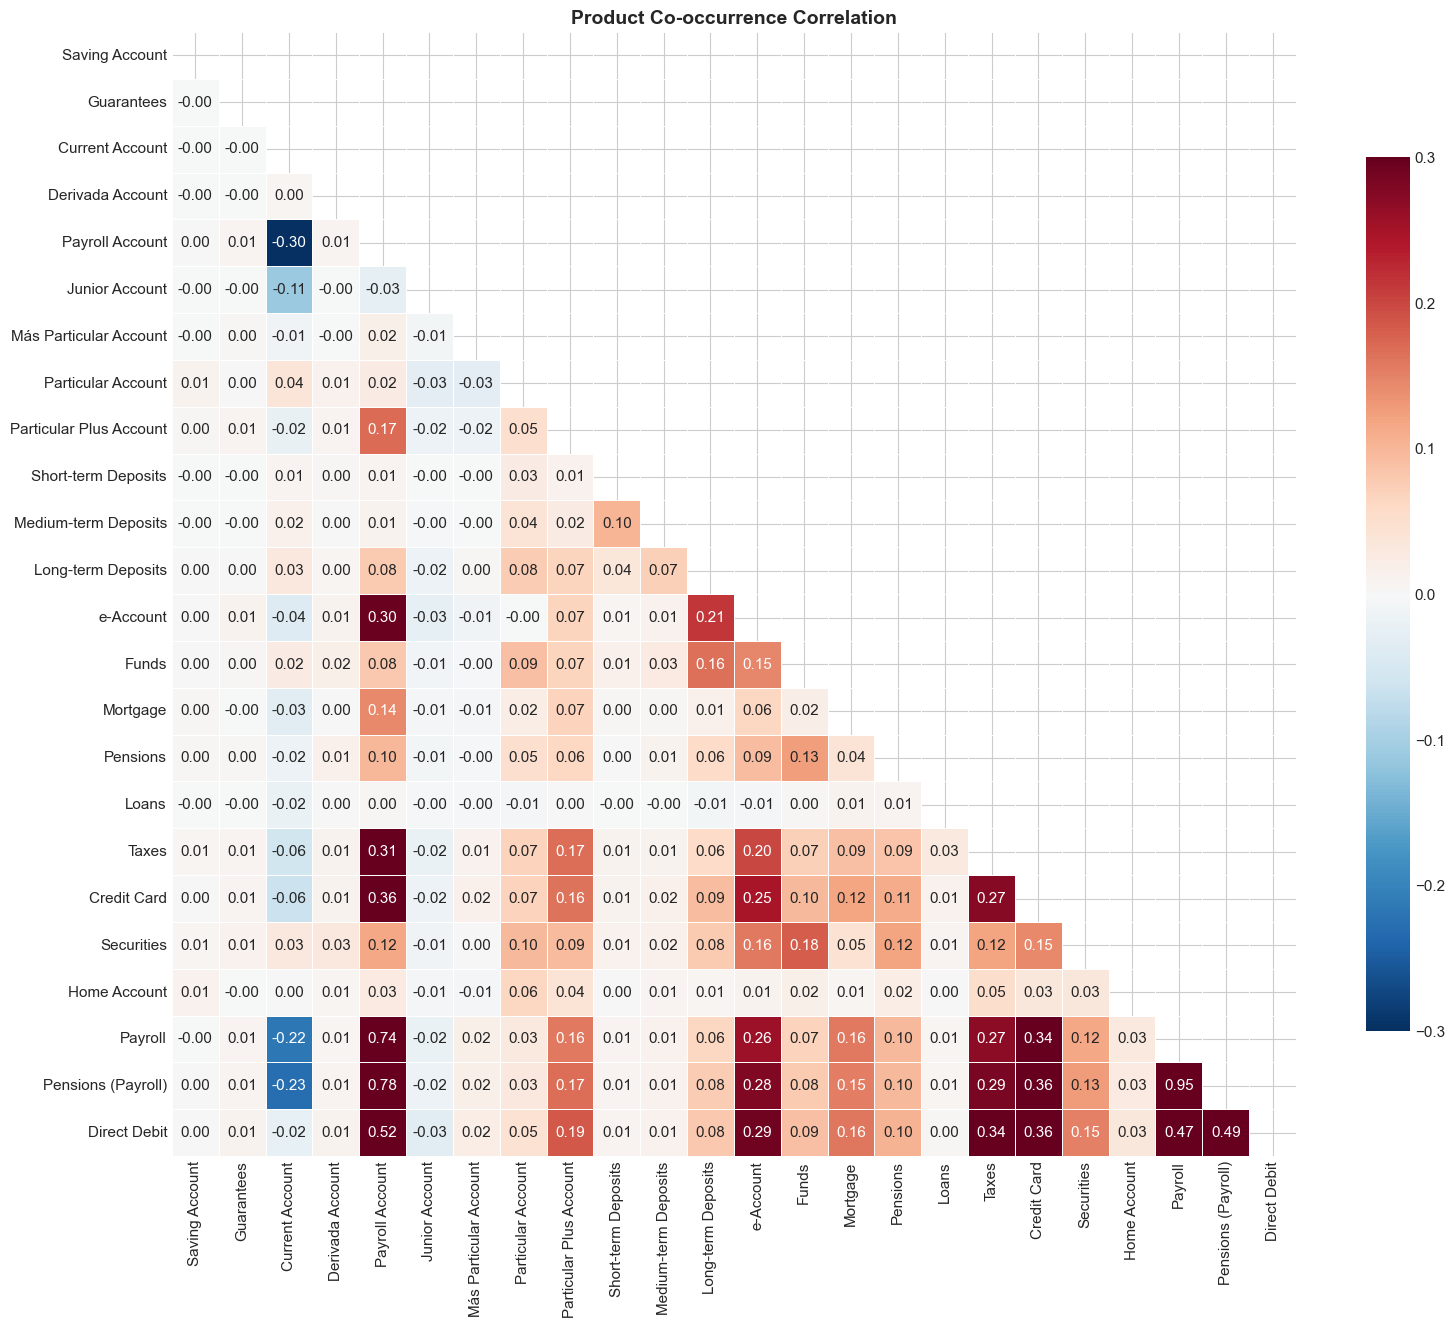

In [12]:
# Product co-occurrence heatmap (latest month)
product_corr = latest[product_cols].corr()

# Rename for readability
product_corr.index = [product_names.get(c, c) for c in product_corr.index]
product_corr.columns = [product_names.get(c, c) for c in product_corr.columns]

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(product_corr, dtype=bool))
sns.heatmap(product_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.3, vmax=0.3, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Product Co-occurrence Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/product_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

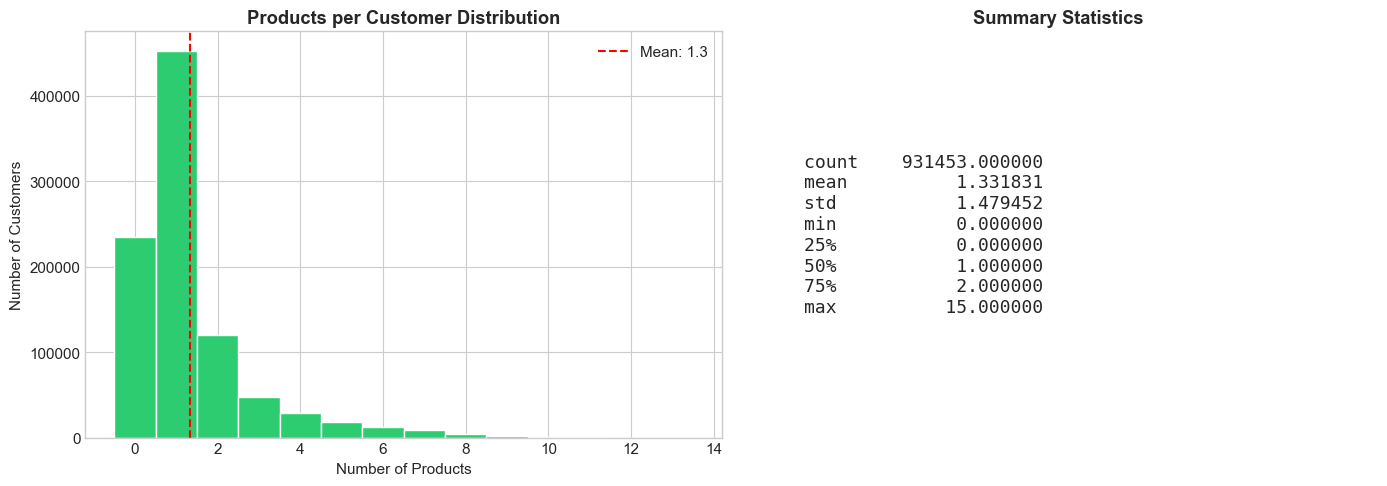

In [13]:
# Products per customer distribution
latest['total_products'] = latest[product_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(latest['total_products'], bins=range(0, 15), color='#2ecc71', edgecolor='white', align='left')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Products per Customer Distribution', fontweight='bold')
axes[0].axvline(latest['total_products'].mean(), color='red', linestyle='--', label=f'Mean: {latest["total_products"].mean():.1f}')
axes[0].legend()

# Summary stats
stats_text = latest['total_products'].describe().to_string()
axes[1].text(0.1, 0.5, stats_text, transform=axes[1].transAxes, fontsize=13, fontfamily='monospace', verticalalignment='center')
axes[1].set_title('Summary Statistics', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/products_per_customer.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Customer Demographics

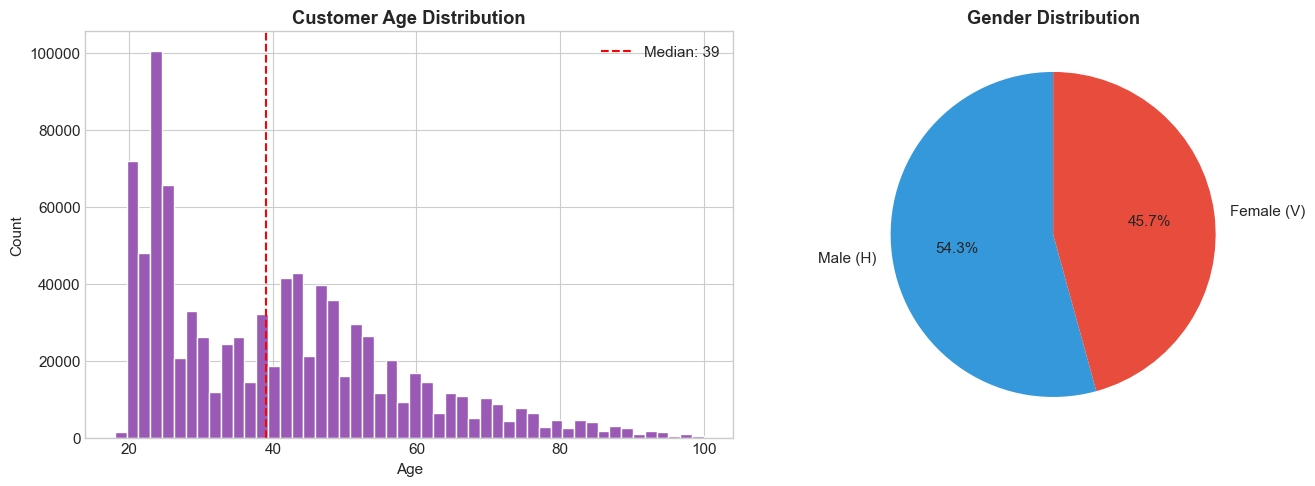

In [14]:
# Age distribution
latest['age'] = pd.to_numeric(latest['age'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
valid_age = latest['age'].dropna()
valid_age = valid_age[(valid_age >= 18) & (valid_age <= 100)]
axes[0].hist(valid_age, bins=50, color='#9b59b6', edgecolor='white')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Customer Age Distribution', fontweight='bold')
axes[0].axvline(valid_age.median(), color='red', linestyle='--', label=f'Median: {valid_age.median():.0f}')
axes[0].legend()

# Gender split
gender_counts = latest['sexo'].value_counts()
axes[1].pie(gender_counts.values, labels=['Male (H)', 'Female (V)'], autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90)
axes[1].set_title('Gender Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/demographics.png', dpi=150, bbox_inches='tight')
plt.show()

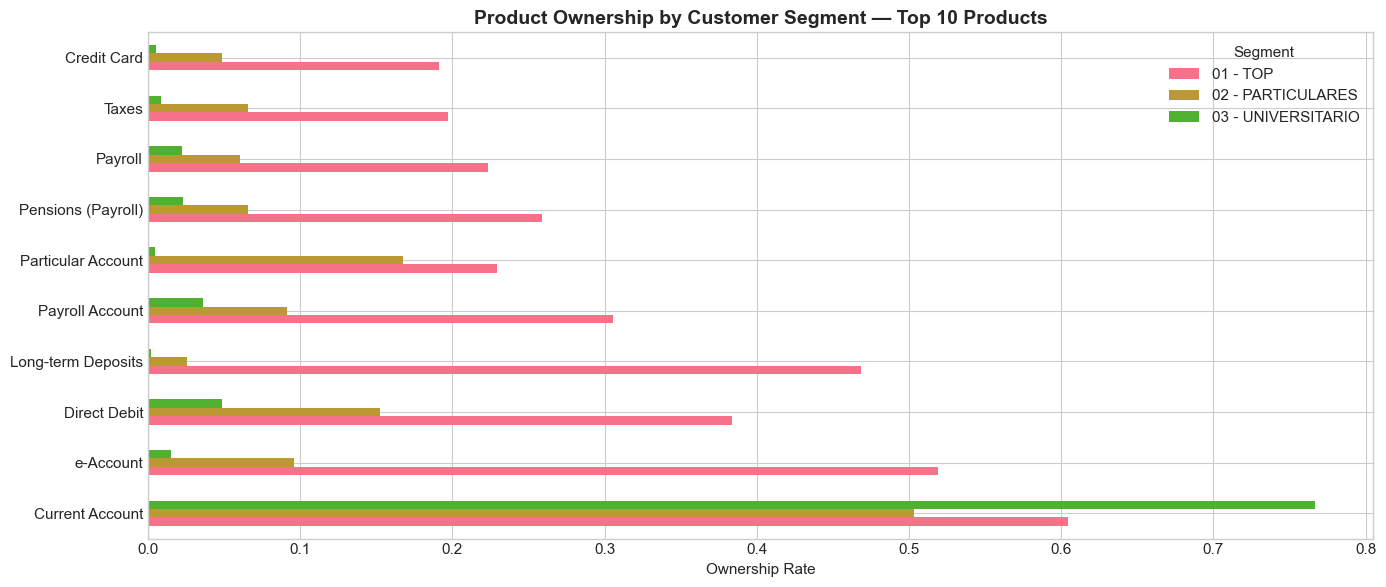

In [15]:
# Customer segment analysis
segment_products = latest.groupby('segmento')[product_cols].mean()
segment_products.columns = [product_names.get(c, c) for c in segment_products.columns]

# Top 10 products by overall rate
top10 = segment_products.mean().nlargest(10).index

fig, ax = plt.subplots(figsize=(14, 6))
segment_products[top10].T.plot(kind='barh', ax=ax)
ax.set_xlabel('Ownership Rate')
ax.set_title('Product Ownership by Customer Segment — Top 10 Products', fontsize=14, fontweight='bold')
ax.legend(title='Segment')
plt.tight_layout()
plt.savefig('../outputs/segment_products.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. New Product Additions (Target Variable)

The target variable for our model: **which products did a customer newly add in a given month?**

Customers in both months: 926,663


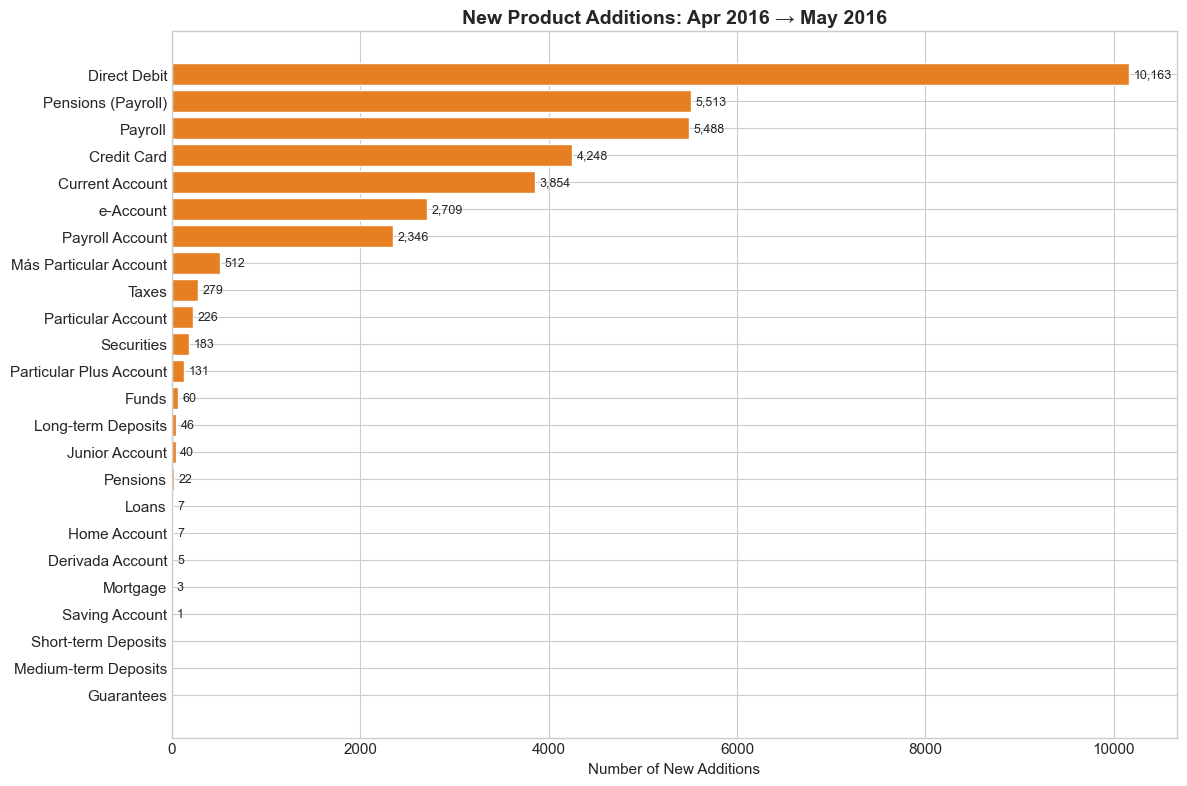


Customers who added at least one product: 3.01%


In [16]:
# Calculate new product additions month-over-month
# Sort by customer and date
df = df.sort_values(['ncodpers', 'fecha_dato']).reset_index(drop=True)

# For each customer, find products that changed from 0 to 1
# We'll do this for the last month pair as a demo
months = sorted(df['fecha_dato'].unique())
prev_month = months[-2]
curr_month = months[-1]

prev_data = df[df['fecha_dato'] == prev_month][['ncodpers'] + product_cols].set_index('ncodpers')
curr_data = df[df['fecha_dato'] == curr_month][['ncodpers'] + product_cols].set_index('ncodpers')

# Find common customers
common = prev_data.index.intersection(curr_data.index)
print(f'Customers in both months: {len(common):,}')

# New additions: was 0 last month, is 1 this month
prev_aligned = prev_data.loc[common].fillna(0)
curr_aligned = curr_data.loc[common].fillna(0)
new_additions = ((prev_aligned == 0) & (curr_aligned == 1)).astype(int)

# Count new additions per product
addition_counts = new_additions.sum().sort_values(ascending=True)
addition_labels = [product_names.get(c, c) for c in addition_counts.index]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(addition_labels, addition_counts.values, color='#e67e22', edgecolor='white')
ax.set_xlabel('Number of New Additions')
ax.set_title(f'New Product Additions: {prev_month.strftime("%b %Y")} → {curr_month.strftime("%b %Y")}', 
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, addition_counts.values):
    if val > 0:
        ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/new_additions.png', dpi=150, bbox_inches='tight')
plt.show()

# Percentage of customers who added any product
any_addition = (new_additions.sum(axis=1) > 0).mean()
print(f'\nCustomers who added at least one product: {any_addition:.2%}')

## 6. Key Findings & Next Steps

### Findings
*(Fill in after running the notebook)*
- [ ] Which products are most/least popular?
- [ ] Are there clear product clusters or bundles?
- [ ] What percentage of customers add new products monthly?
- [ ] Any data quality issues that need attention?
- [ ] Demographic patterns in product ownership?

### Data Quality Notes
*(Fill in after running)*
- Missing values strategy: ...
- Outlier handling: ...
- Columns to drop: ...

### Next Steps → Phase 2: Feature Engineering
- Create lag features (product ownership in previous months)
- Build RFM-style metrics per customer
- Calculate product velocity (rate of change)
- Encode demographics properly
- Define train/validation split strategy